In [265]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize, theory, cluster_utils, data
from matplotlib.pyplot import cm

import utils

%load_ext autoreload
%autoreload 2

local_path = '/Users/haozheshan/Dropbox/codes/gp_continual_learning/cluster_results'

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.8, 1.5]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1

def savefig():
    plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Load a single dataset for analysis

In [295]:
batch_name = '4x1000_mnist_1L_fW0_permute0.2_resample1_interpolate'
organize_key = 'lambda_val'
VIEW_NAIVE_GP = False

if VIEW_NAIVE_GP:
    path = local_path + '/naive_gp/'
else:
    path = local_path
organizer =\
    cluster_utils.ClusterResultOrganizer(path, batch_name=batch_name, max_ind=500)
organizer.load_all()

all_test_acc = organizer.organize_results('test acc', organize_key)
all_train_acc = organizer.organize_results('train acc', organize_key)
all_test_var = organizer.organize_results('test var', organize_key)
all_train_var = organizer.organize_results('train var', organize_key)
all_test_loss = organizer.organize_results('test loss', organize_key)
all_train_loss = organizer.organize_results('train loss', organize_key)

print('available keys:', all_test_loss.keys())


def check_consistency(args1, args2):
    for key in ['n_tasks', 'P', 'dataset']:
        if vars(args1)[key] != vars(args2)[key]:
            print(f'key "{key}" appears inconsistent between args.')
# batch_organizer =\
#     cluster_utils.ClusterResultOrganizer(local_path, batch_name='1x1000_fashion_permute0_BATCH_RESULTS')
# batch_organizer.load_all()
# batch_acc = batch_organizer.organize_results('batch acc', 'depth')[str(organizer.args.depth)]
# check_consistency(organizer.args, batch_organizer.args)

title_text = f'{organizer.args.dataset}, P={organizer.args.P},' +\
          f'\n {organizer.args.n_tasks} tasks, permutation:{bool(organizer.args.permutation)},Depth:{organizer.args.depth}' +\
            f', \n fixed w:{bool(organizer.args.fixed_w)}'

=================== Cluster organizer ===================
140 data objects loaded from folder "4x1000_mnist_1L_fW0_permute0.2_resample1_interpolate".
=================== Cluster organizer ===================
Organizer: data with key <<test var>> were not found
Organizer: data with key <<train var>> were not found
available keys: dict_keys(['0.001', '1.0', '5.0', '10.0', '50.0', '100.0', '500.0', '1000.0', '5000.0', '10000.0', '50000.0', '100000.0', '500000.0', '10000000.0'])


Text(0.5, 1.0, 'test loss, last task')

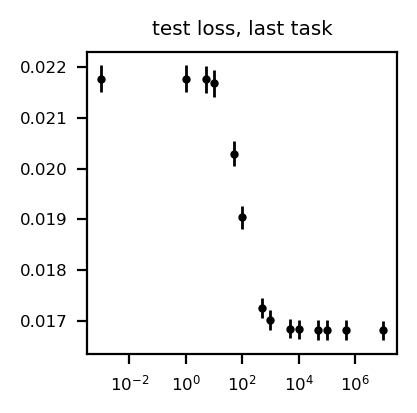

In [296]:
plotted_obj = all_test_loss
title_name = 'test loss'

plt.figure(figsize=(2, 2))

for key in plotted_obj.keys():
    plt.errorbar(float(key),
                 plotted_obj[key].mean(0)[-1, -1],
                 plotted_obj[key].std(0)[-1, -1] / np.sqrt(plotted_obj[key].shape[0]),
                 color='k', marker='o', markersize=2)
plt.xscale('log')
plt.title(title_name + ', last task')

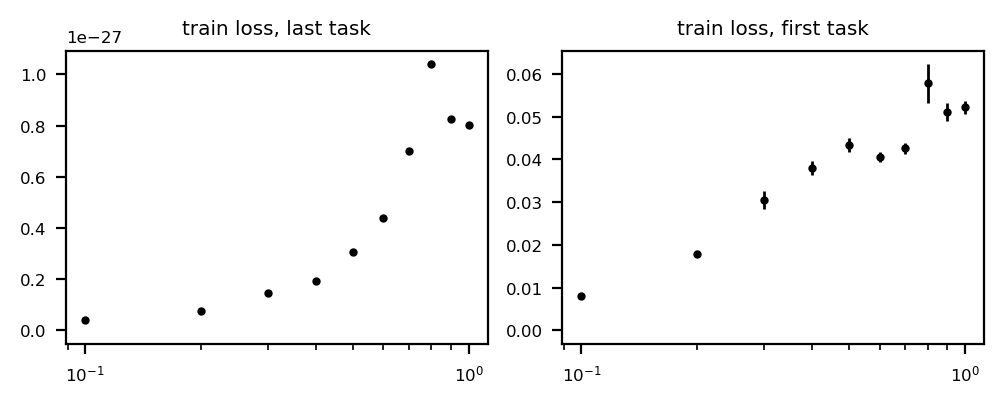

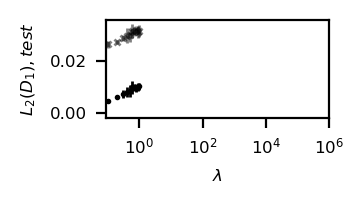

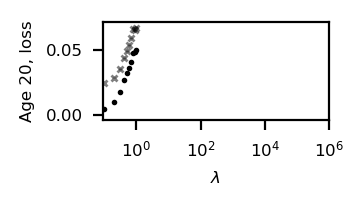

In [193]:
plotted_obj = all_train_loss
title_name = 'train loss'

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 2))
axes = axes.ravel()

plt.sca(axes[0])

for key in plotted_obj.keys():
    plt.errorbar(float(key),
                 plotted_obj[key].mean(0)[-1, -1],
                 plotted_obj[key].std(0)[-1, -1] / np.sqrt(plotted_obj[key].shape[0]),
                 color='k', marker='o', markersize=2)
plt.xscale('log')
plt.title(title_name + ', last task')

plt.sca(axes[1])
for key in plotted_obj.keys():
    plt.errorbar(float(key),
                 plotted_obj[key].mean(0)[0, -1],
                 plotted_obj[key].std(0)[0, -1] / np.sqrt(plotted_obj[key].shape[0]),
                 color='k', marker='o', markersize=2)
plt.title(title_name + ', first task')
plt.xscale('log')

plt.tight_layout()


plt.rcParams['figure.figsize'] = [1.8, 1]

plt.figure()
for key in all_train_loss.keys():
    plt.errorbar(float(key),
                 all_train_loss[key].mean(0)[0, 1],
                 all_train_loss[key].std(0)[0, 1],
                 color='k', marker='o', markersize=1)

for key in all_test_loss.keys():
    plt.errorbar(float(key),
                 all_test_loss[key].mean(0)[0, 1],
                 all_test_loss[key].std(0)[0, 1],
                 color='k', marker='x', markersize=2, alpha=0.5)

plt.xscale('log')
plt.xticks(10**(np.arange(4)*2))
plt.ylabel('$L_2 (D_1), test$')
plt.xlabel('$\lambda$')
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

# plot tasks with a certain age as a function of time
plt.figure()
AGE = 20
for key in all_train_loss.keys():
    all_tasks_with_specific_age = []
    for i in range(all_train_loss[key].shape[1] - AGE):
        all_tasks_with_specific_age += list(all_train_loss[key][:, i, i+AGE])
    plt.errorbar(float(key),
                 np.mean(all_tasks_with_specific_age),
                 np.std(all_tasks_with_specific_age) / np.sqrt(len(all_tasks_with_specific_age)),
                 color='k', marker='o', markersize=1)

for key in all_test_loss.keys():
    all_tasks_with_specific_age = []
    for i in range(all_test_loss[key].shape[1] - AGE):
        all_tasks_with_specific_age += list(all_test_loss[key][:, i, i+AGE])
    plt.errorbar(float(key),
                 np.mean(all_tasks_with_specific_age),
                 np.std(all_tasks_with_specific_age) / np.sqrt(len(all_tasks_with_specific_age)),
                 color='k', marker='x', markersize=2, alpha=0.5)

plt.xscale('log')
plt.xticks(10**(np.arange(4)*2))
plt.ylabel(f'Age {AGE}, loss')
plt.xlabel('$\lambda$')
plt.tight_layout()
# plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

# Plot values of interest over keys

Text(0, 0.5, 'trainz accuracy averaged over task')

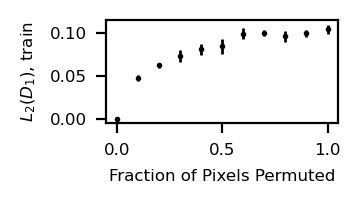

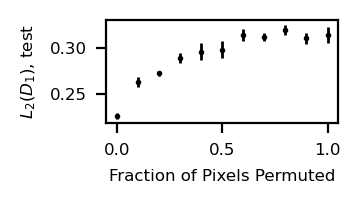

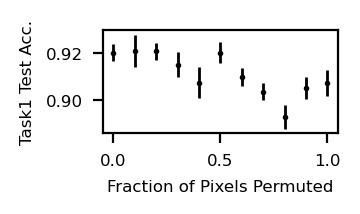

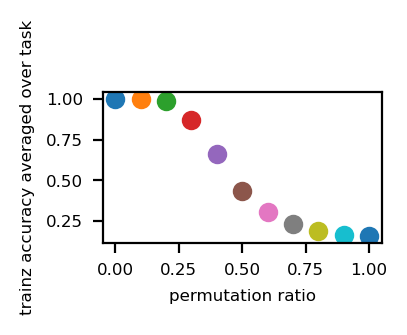

In [194]:
def plot_value_over_keys(value, factor=1):

    plt.figure()
    for key in value.keys():
        num_seeds = value[key].shape[0]
        plt.errorbar(float(key), value[key][:, 0, 1].mean() * factor,
                     value[key][:, 0, 1].std(0) * factor / np.sqrt(value[key].shape[0]), marker='o', color='k', markersize=1)

plt.rcParams['figure.figsize'] = [1.8, 1]
plot_value_over_keys(all_train_loss, factor=10)
plt.xlabel('Fraction of Pixels Permuted')
plt.ylabel('$L_2(D_1)$, train')
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

plot_value_over_keys(all_test_loss, factor=10)
plt.xlabel('Fraction of Pixels Permuted')
plt.ylabel('$L_2(D_1)$, test')
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

plot_value_over_keys(all_test_acc)
plt.xlabel('Fraction of Pixels Permuted')
plt.ylabel('Task1 Test Acc.')
plt.tight_layout()
# plt.yticks([0.9, 0.91, 0.92, 0.93])
# plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')


plt.figure()
for key in all_train_loss.keys():
    plt.scatter(float(key), all_train_acc[key][:, :, 1].mean())
plt.xlabel('permutation ratio')
plt.ylabel('trainz accuracy averaged over task')

mnist, P=1000,
 30 tasks, permutation:True,Depth:1, 
 fixed w:False


Text(0, 0.5, 'Test Loss')

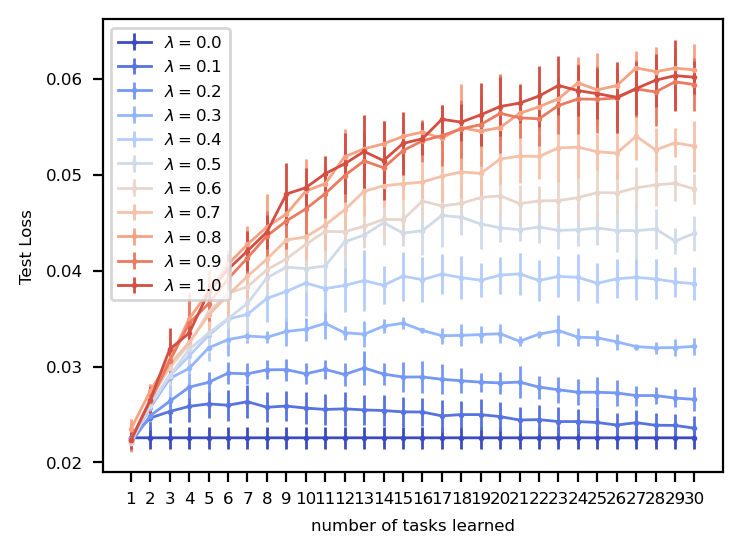

In [195]:
def plot_acc(all_acc, include_params=None, benchmark=True, tasks_so_far=True):
    plt.figure(figsize=(4, 3))
    param_key = None
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(all_acc.keys()) + 1))
    for param_i, param_key in enumerate(all_acc.keys()):
        if include_params is not None:
            if param_key not in include_params:
                continue

        mean_acc_over_tasks = np.zeros((all_acc[param_key].shape[0],
                                        all_acc[param_key].shape[2]))
        for i in range(all_acc[param_key].shape[2]):
            if tasks_so_far:
                mean_acc_over_tasks[:, i] = all_acc[param_key][:, :i+1, i].mean(1)
            else:
                mean_acc_over_tasks[:, i] = all_acc[param_key][:, :, i].mean(1)
        num_seeds, num_tasks = mean_acc_over_tasks.shape
        plt.errorbar(np.arange(num_tasks) + 1, mean_acc_over_tasks.mean(0),
                     mean_acc_over_tasks.std(0), label=f'$\lambda=${param_key}',
                     color=colors[param_i], marker='o', markersize=1)

    if benchmark:
        batch_acc_mean = batch_acc.mean(0)

        batch_acc_mean[0] = mean_acc_over_tasks.mean(0)[0]
        # plt.axhline(batch_acc_mean[0], ls='--', color='k')
        plt.plot(np.arange(all_acc[param_key].shape[2]) + 1, batch_acc_mean, color='k', label='batch')
        # plt.errorbar(np.arange(all_acc[param_key].shape[2]) + 1, batch_acc.mean(0),
        #              batch_acc.std(0) / np.sqrt(all_acc[param_key].shape[0]), color='k', label='batch')
        # plt.axhline(batch_acc.mean(0)[0] - 0.01, color='k', ls='--')
    plt.legend()

    plt.xlabel('number of tasks learned')
    plt.xticks(np.arange(all_acc[param_key].shape[2]) + 1)
    print(title_text)



plot_acc(all_test_loss, include_params=None,
         benchmark=False, tasks_so_far=True)

plt.ylabel('Test Loss')

# Same as the last cell, but specifically for making making plots over premutation strength

mnist, P=1000,
 20 tasks, permutation:True,Depth:1, 
 fixed w:False


Text(0, 0.5, 'Mean Test Loss on Trained Tasks')

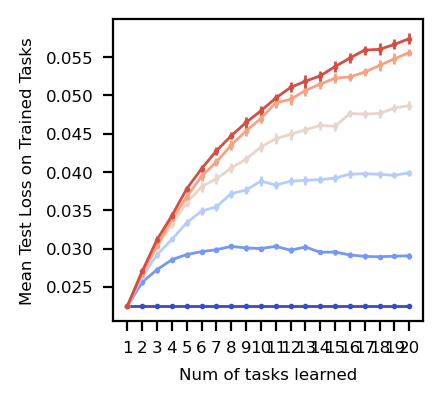

In [142]:
def plot_acc(all_acc, include_params=None, benchmark=True, tasks_so_far=True):
    plt.figure(figsize=(2, 2))
    param_key = None
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(all_acc.keys()) + 1))
    for param_i, param_key in enumerate(all_acc.keys()):
        if include_params is not None:
            if param_key not in include_params:
                continue

        mean_acc_over_tasks = np.zeros((all_acc[param_key].shape[0],
                                        all_acc[param_key].shape[2]))
        for i in range(all_acc[param_key].shape[2]):
            if tasks_so_far:
                mean_acc_over_tasks[:, i] = all_acc[param_key][:, :i+1, i].mean(1)
            else:
                mean_acc_over_tasks[:, i] = all_acc[param_key][:, :, i].mean(1)
        num_seeds, num_tasks = mean_acc_over_tasks.shape
        plt.errorbar(np.arange(num_tasks) + 1, mean_acc_over_tasks.mean(0),
                     mean_acc_over_tasks.std(0) / np.sqrt(mean_acc_over_tasks.shape[0]), label=f'$\lambda=${param_key}',
                     color=colors[param_i], marker='o', markersize=1)

    if benchmark:
        batch_acc_mean = batch_acc.mean(0)

        batch_acc_mean[0] = mean_acc_over_tasks.mean(0)[0]
        # plt.axhline(batch_acc_mean[0], ls='--', color='k')
        plt.plot(np.arange(all_acc[param_key].shape[2]) + 1, batch_acc_mean, color='k', label='batch')
        # plt.errorbar(np.arange(all_acc[param_key].shape[2]) + 1, batch_acc.mean(0),
        #              batch_acc.std(0) / np.sqrt(all_acc[param_key].shape[0]), color='k', label='batch')
        # plt.axhline(batch_acc.mean(0)[0] - 0.01, color='k', ls='--')
    # plt.legend()

    plt.xlabel('Num of tasks learned')
    plt.xticks(np.arange(all_acc[param_key].shape[2]) + 1)
    print(title_text)



plot_acc(all_test_loss, include_params=['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'],
         benchmark=False, tasks_so_far=True)

plt.ylabel('Mean Test Loss on Trained Tasks')

In [314]:
plt.figure()
plt.errorbar(np.arange(1, 11), all_test_acc['1000000.0'].mean(0)[0], all_test_acc['1000000.0'].std(0)[0])
plt.xlabel('Number of Tasks Learned')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.xticks(np.arange(1, 11))
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

KeyError: '1000000.0'

<Figure size 360x200 with 0 Axes>

## Plot over key parameters

Text(0.5, 1.0, 'mnist, P=1000,\n 20 tasks, permutation:True,Depth:1, \n fixed w:True')

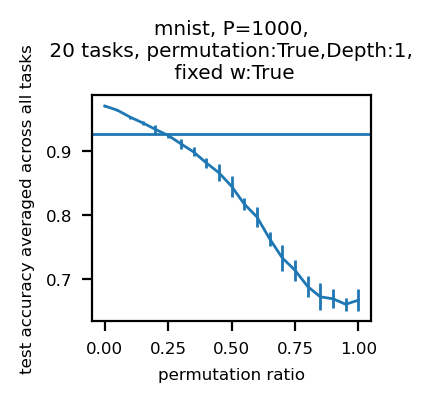

In [26]:
x_axis = []
data_stack = []
for _key in all_test_acc.keys():
    x_axis.append(float(_key))
    data_stack.append(all_test_acc[_key][:, :, -1].mean(1))

x_axis = np.array(x_axis)
data_stack = np.array(data_stack)


plt.figure()
plt.errorbar(x_axis, data_stack.mean(1), data_stack.std(1))
plt.xlabel('permutation ratio')
plt.ylabel('test accuracy averaged across all tasks')
plt.axhline(all_test_acc['0.0'][:, :, 0].mean(), label='single task performance')
plt.title(title_text)


Text(0, 0.5, 'prediction variance on test/$\\sigma^2$')

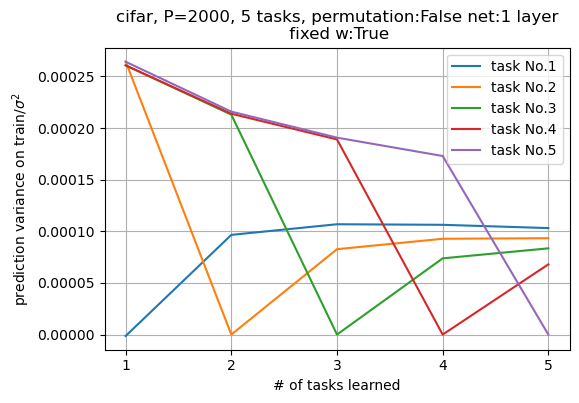

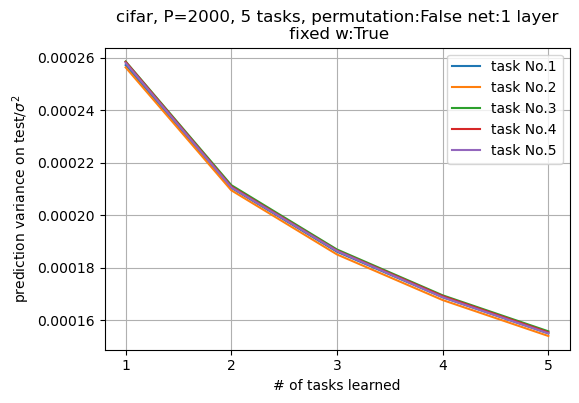

In [31]:
def plot_var(var):
    plt.figure(dpi=100)
    for task_ind in range(organizer.args.n_tasks):
        plt.plot(np.arange(organizer.args.n_tasks) + 1,
                 var.mean(0)[task_ind] / organizer.args.sigma**2, label=f'task No.{task_ind+1}')

    plt.title(title_text)
    plt.xlabel('# of tasks learned')
    _ = plt.xticks(np.arange(organizer.args.n_tasks) + 1)
    plt.legend()
    plt.grid()

plot_var(all_train_var['1000.0'])
plt.ylabel('prediction variance on train/$\sigma^2$')
plot_var(all_test_var['1000.0'])
plt.ylabel('prediction variance on test/$\sigma^2$')

mnist, P=1000, 10 tasks, permutation:False,DEPTH:10 net:10 layers, 
 fixed w:False
mnist, P=1000, 10 tasks, permutation:False,DEPTH:10 net:10 layers, 
 fixed w:False


Text(0, 0.5, 'Train Accuracy (avg. over learned tasks)')

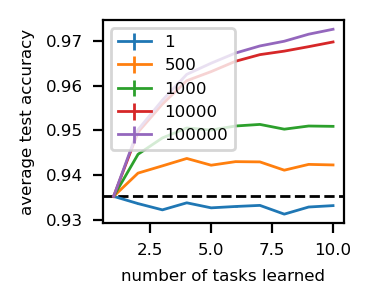

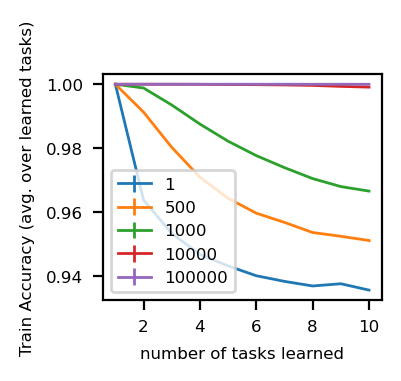

In [31]:
def get_acc_so_far(acc_matrix):
    # acc_matrix shape: num_seeds * num_tasks * num_times
    num_seeds, num_tasks, num_times = acc_matrix.shape
    acc_sofar = np.zeros(num_times)
    var_sofar = np.zeros(num_times)
    for i in range(num_tasks):
        acc_sofar[i] = acc_matrix[:, :i+1, i].mean()
        var_sofar[i] = acc_matrix[:, :i+1, i].mean(axis=1).var()
    return acc_sofar, var_sofar

def plot_acc_sofar(all_acc, benchmark=True):
    plt.figure()
    param_key = None
    for param_key in all_acc.keys():
        if param_key not in ['1.0', '500.0', '1000.0', '10000.0', '100000.0']:
            continue
        num_timepoints = all_acc[param_key].shape[2]
        plt.errorbar(np.arange(num_timepoints) + 1, *get_acc_so_far(all_acc[param_key]), label=f'{param_key[:-2]}')

    if benchmark:
        plt.axhline(all_acc[param_key].mean(0)[0, 0], color='k', ls='--')

    # plt.grid()
    # plt.ylim(0.5, 1.05)
    plt.legend()
    plt.xlabel('number of tasks learned')
    # plt.xticks(np.arange(all_acc[param_key].shape[2]) + 1)

    # plt.title(title_text)
    print(title_text)


plot_acc_sofar(all_test_acc, benchmark=True)
plt.ylabel('average test accuracy')

plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

plot_acc_sofar(all_train_acc, benchmark=False)
plt.ylabel('Train Accuracy (avg. over learned tasks)')


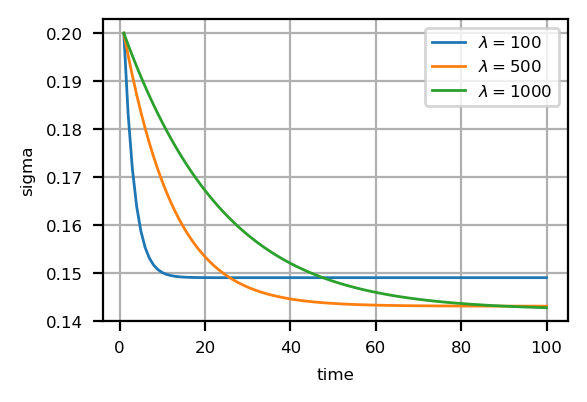

In [276]:
lambs = [100, 500, 1000]

plt.figure()
for _lambda in lambs:
    w_vars = theory.compute_W_var(0.04, _lambda, 100)
    plt.plot(np.arange(1, 101), np.sqrt(np.diag(w_vars)), label=f'$\lambda=${_lambda}')
plt.xlabel('time')
plt.ylabel('sigma')
plt.grid()
plt.legend()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'w_std.svg')

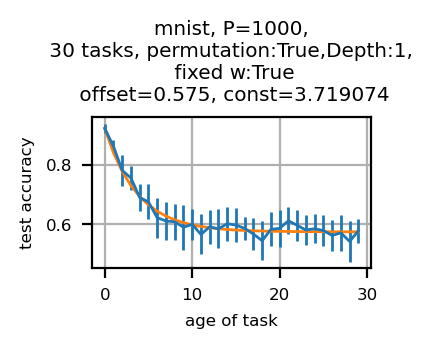

In [50]:
key = '10000000.0'
mean_test = all_test_acc[key].mean(0)
std_test = all_test_acc[key].std(0)
xaxis = np.arange(organizer.args.n_tasks)

def exp_fit_and_plot(xaxis, y, p0, **kwargs):
    init_offset = y[0]
    offset, time_constant = scipy.optimize.curve_fit(lambda t,a,b: a + (init_offset - a) * np.exp(-t / b), xaxis, y, p0=p0)[0]
    plt.plot(xaxis, offset + (init_offset - offset) * np.exp(-xaxis / time_constant), **kwargs)
    return offset, time_constant


plt.figure()

init_offset = mean_test[-1, -1]

plt.errorbar(xaxis, mean_test[:, -1][::-1], std_test[:, -1][::-1])
offset, base = exp_fit_and_plot(xaxis, mean_test[:, -1][::-1], (0.9, 0.9))
plt.title(title_text + f'\n offset={offset:.3f}, const={base:3f}')
plt.xlabel('age of task')
plt.ylabel('test accuracy')
plt.grid()
# plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'pMNIST_10l_age.svg')

# plt.xscale('log')
# plt.yscale('log')
# plt.plot(np.arange(1, 40), 0.45 / np.arange(1, 40)**0.5 + 0.35)
# plt.plot(mean_test[:, -10])

# Things as a function of task age

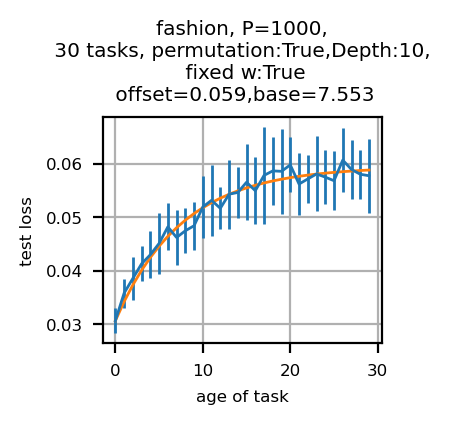

In [45]:
key = '1000000.0'
mean_test_loss = all_test_loss[key].mean(0)
std_test_loss = all_test_loss[key].std(0)
xaxis = np.arange(organizer.args.n_tasks)
plt.figure()


plt.errorbar(xaxis, mean_test_loss[:, -1][::-1], std_test_loss[:, -1][::-1])
offset, base = utils.exp_fit_and_plot(xaxis, mean_test_loss[:, -1][::-1], (0.9, 0.9))
plt.title(title_text + f'\n offset={offset:.3f},base={base:.3f}')
plt.xlabel('age of task')
plt.ylabel('test loss')
plt.grid()
# plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'pMNIST_10l_age.svg')


# Plot things from multiple files

=================== Cluster organizer ===================
130 data objects loaded from folder "30x1000_mnist_1L_fW0_permute1_resample0".
=================== Cluster organizer ===================
=================== Cluster organizer ===================
50 data objects loaded from folder "30x1000_mnist_3L_fW0_permute1".
=================== Cluster organizer ===================
=================== Cluster organizer ===================
60 data objects loaded from folder "30x1000_mnist_6L_fW0_permute1_resample0".
=================== Cluster organizer ===================
=================== Cluster organizer ===================
36 data objects loaded from folder "30x1000_mnist_10L_fW0_permute1_resample0".
=================== Cluster organizer ===================


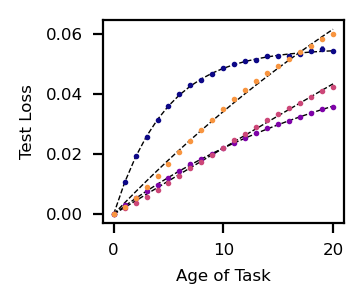

In [299]:
# folder_names = ['30x500_mnist_1L_fW0_permute1',
#                 '30x500_mnist_3L_fW0_permute1',
#                 '30x500_mnist_6L_fW0_permute1',
#                 '30x500_mnist_10L_fW0_permute1']
# folder_names = [
#                 '30x500_mnist_6L_fW0_permute1_resample0',
#                 '30x500_mnist_10L_fW0_permute1_resample0']
# folder_names = ['20x500_mnist_1L_fW0_permute1_resample0_1e_9',
#                 '20x500_mnist_1L_fW0_permute1']
folder_names = ['30x1000_mnist_1L_fW0_permute1_resample0',
                '30x1000_mnist_3L_fW0_permute1',
                '30x1000_mnist_6L_fW0_permute1_resample0',
                '30x1000_mnist_10L_fW0_permute1_resample0']
# folder_names = ['30x1000_mnist_1L_fW1_permute1_NO_RESAMPLE',
#                 '30x1000_mnist_3L_fW1_permute1_NO_RESAMPLE',
#                 '30x1000_mnist_6L_fW1_permute1_NO_RESAMPLE',
#                 '30x1000_mnist_10L_fW1_permute1_NO_RESAMPLE',]
#                 '20x500_mnist_3L_fW0_permute1',
#                 '20x500_mnist_6L_fW0_permute1']
# folder_names = ['40x1000_mnist_1L_fW1_permute1',
#                 '40x1000_mnist_10L_fW1_permute1']
# folder_names = ['10x1000_mnist_1L_fW0_permute1', '10x1000_mnist_1L_fW1_permute1']
key_of_data_to_plot = 'train loss'
VIEW_NAIVE_GP = False
MAX_AGE = 20

plt.figure(figsize=(1.8, 1.5))

cmap = cm.plasma(np.arange(4) / 4)
offsets = []
time_constants = []
for i, f_name in enumerate(folder_names):
    path = local_path
    if VIEW_NAIVE_GP:
        path += '/naive_gp/'
    _org = cluster_utils.ClusterResultOrganizer(path, batch_name=f_name)
    _org.load_all()
    try:
        _data = _org.organize_results(key_of_data_to_plot, 'lambda_val')['10000.0'][:, :, :]
    except:
        _data = _org.organize_results(key_of_data_to_plot, 'lambda_val')['10000000.0'][:, :, :]
    _num_tasks = _data.shape[1]
    tasks_over_ages = [[] for _i in range(MAX_AGE + 1)]
    for task_ind in range(_num_tasks):
        for _age in range(_num_tasks - task_ind):
            if _age > MAX_AGE:
                break
            tasks_over_ages[_age] += list(_data[:, task_ind, task_ind + _age])

    mean_for_fitting = []
    for _age in range(MAX_AGE + 1):
        mean_for_fitting.append(np.mean(tasks_over_ages[_age]))

        plt.errorbar(_age, np.mean(tasks_over_ages[_age]),
                     np.std(tasks_over_ages[_age]) / np.sqrt(len(tasks_over_ages[_age])),
                     marker='o', color=cmap[i], markersize=1)

    offset, time_constant = utils.exp_fit_and_plot(np.arange(MAX_AGE + 1),
                                               mean_for_fitting, (0.9, 0.9), color='k', lw=0.5,
                                               plot_axis=np.arange(MAX_AGE + 1),
                                                   x_offset=0, ls='--')

    # tasks_over_ages = [[] for _i in range(_data.shape[1])]
    # max_age = _data.shape[1] - 10 + 1
    # for _i in range(_data.shape[1]):
    #     for _age in range(_data.shape[1] - _i):
    #         tasks_over_ages[_age]+= list(_data[:, _i, _i + _age])
    #
    # mean_for_fitting = []
    # print(np.mean(tasks_over_ages[0]))
    # for _age in range(max_age):
    #     mean_for_fitting.append(np.mean(tasks_over_ages[_age]))
    #
    #     plt.errorbar(_age, np.mean(tasks_over_ages[_age]),
    #                  np.std(tasks_over_ages[_age]) / np.sqrt(len(tasks_over_ages[_age])),
    #                  marker='o', color=cmap[i], markersize=1)
    #
    # # plt.errorbar(xaxis, _mean[:, -1][::-1], _std[:, -1][::-1], label=_org.args.depth)
    # offset, time_constant = utils.exp_fit_and_plot(np.arange(max_age),
    #                                                mean_for_fitting, (0.9, 0.9), color='k', lw=0.5,
    #                                                plot_axis=np.arange(max_age))
    offsets.append(offset)
    time_constants.append(time_constant)
    # print(f'offset{offset:.3f}, time constant{base:.3f}')
plt.xlabel('Age of Task')
plt.ylabel('Test Loss')
# plt.legend()
# plt.xlim(-1, 5)
# plt.grid()
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')


# Same as the cell above but for plotting over different permutations

In [150]:
organizer.args

Namespace(f=None, cluster=1, BATCH_NAME='20x1000_mnist_1L_resample0_different_permutation', TRIAL_IND=219, P=1000, P_test=500, n_tasks=20, T=0.0, sigma=0.2, depth=1, seed=19, fixed_w=0, lambda_val=10000000.0, dataset='mnist', permutation=1.0, n_epochs=1, resample=0, interpolate=0)

In [215]:
DICT_TO_PLOT.keys()

dict_keys(['1.0', '3.0', '10.0', '30.0', '100.0', '300.0', '1000.0', '3000.0', '10000.0', '30000.0', '100000.0', '300000.0', '1000000.0', '3000000.0', '10000000.0'])

=================== Cluster organizer ===================
130 data objects loaded from folder "30x1000_mnist_1L_fW0_permute1_resample0".
=================== Cluster organizer ===================
Namespace(f=None, cluster=1, BATCH_NAME='30x1000_mnist_1L_fW0_permute1_resample0', TRIAL_IND=159, P=1000, P_test=333, n_tasks=30, T=0.0, sigma=0.2, depth=1, seed=9, fixed_w=0, lambda_val=10000000.0, dataset='mnist', permutation=1.0, n_epochs=1, resample=0, interpolate=0)


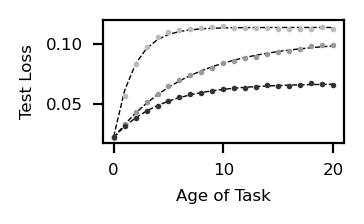

In [279]:
batch_name = '30x1000_mnist_1L_fW0_permute1_resample0'
organize_key = 'lambda_val'
VIEW_NAIVE_GP = False
MAX_AGE = 20
KEY_TO_PLOT = 'test loss'
include_params = ['100.0', '1000.0', '1000000.0']
# include_params = ['0.2', '0.6',  '1.0']
if VIEW_NAIVE_GP:
    path = local_path + '/naive_gp/'
else:
    path = local_path
organizer =\
    cluster_utils.ClusterResultOrganizer(path, batch_name=batch_name, max_ind=500)
organizer.load_all()
print(organizer.args)

DICT_TO_PLOT = organizer.organize_results(KEY_TO_PLOT, organize_key)

# include_params = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0']


plt.figure(figsize=(1.8, 1.1))
perm_colors = plt.cm.gray_r(np.linspace(0, 1, len(DICT_TO_PLOT.keys()) + 1))
for param_i, param_key in enumerate(DICT_TO_PLOT.keys()):
    if include_params is not None:
        if param_key not in include_params:
            continue

    _data = DICT_TO_PLOT[param_key]
    _num_tasks = _data.shape[1]
    tasks_over_ages = [[] for _i in range(MAX_AGE + 1)]
    for task_ind in range(_num_tasks):
        for _age in range(_num_tasks - task_ind):
            if _age > MAX_AGE:
                break
            tasks_over_ages[_age] += list(_data[:, task_ind, task_ind + _age])

    mean_for_fitting = []
    for _age in range(MAX_AGE + 1):
        mean_for_fitting.append(np.mean(tasks_over_ages[_age]))

        plt.errorbar(_age, np.mean(tasks_over_ages[_age]),
                     np.std(tasks_over_ages[_age]) / np.sqrt(len(tasks_over_ages[_age])),
                     marker='o', color=perm_colors[param_i], markersize=1)

    offset, time_constant = utils.exp_fit_and_plot(np.arange(MAX_AGE + 1),
                                               mean_for_fitting, (0.9, 0.9), color='k', lw=0.5,
                                               plot_axis=np.arange(MAX_AGE + 1),
                                                   x_offset=0, ls='--')
plt.xlabel('Age of Task')
plt.ylabel('Test Loss')
plt.tight_layout()
savefig()

In [262]:
tasks_over_ages[-1]

[]

# Plot performance on task 1 over time

=================== Cluster organizer ===================
50 data objects loaded from folder "30x1000_mnist_1L_fW0_permute1".
=================== Cluster organizer ===================
=================== Cluster organizer ===================
50 data objects loaded from folder "30x1000_mnist_3L_fW0_permute1".
=================== Cluster organizer ===================
=================== Cluster organizer ===================
60 data objects loaded from folder "30x1000_mnist_6L_fW0_permute1_resample0".
=================== Cluster organizer ===================
=================== Cluster organizer ===================
36 data objects loaded from folder "30x1000_mnist_10L_fW0_permute1_resample0".
=================== Cluster organizer ===================


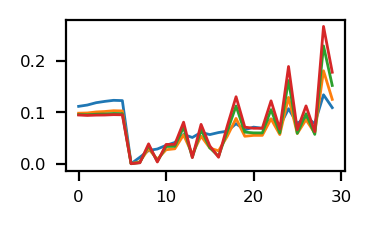

In [345]:
# only print one
key_of_data_to_plot = 'train loss'

folder_names = ['30x1000_mnist_1L_fW0_permute1',
                '30x1000_mnist_3L_fW0_permute1',
    '30x1000_mnist_6L_fW0_permute1_resample0',
                '30x1000_mnist_10L_fW0_permute1_resample0']
for i, f_name in enumerate(folder_names):
    _org = cluster_utils.ClusterResultOrganizer(local_path, batch_name=f_name)
    _org.load_all()
    _data = _org.organize_results(key_of_data_to_plot, 'lambda_val')['100000000.0']
    plt.plot(_data.mean(0)[6])

In [38]:
offsets

[0.08276906811505587,
 0.04066070052551703,
 0.029109533739369878,
 0.02436525020266907]

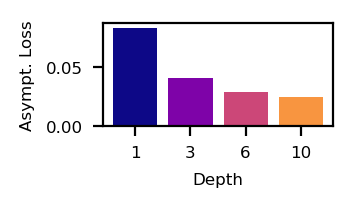

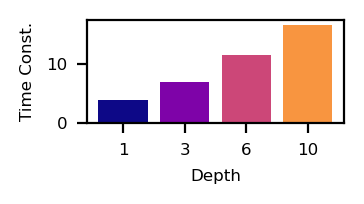

In [37]:
# Bar plots of the time constants etc.
cmap = cm.plasma(np.arange(4) / 4)
plt.figure(figsize=(1.8, 1))
for i in range(4):
    plt.bar([1, 2, 3, 4][i], offsets[i], color=cmap[i])
plt.xticks([1, 2, 3, 4], [1, 3, 6, 10])
plt.xlabel('Depth')
plt.ylabel('Asympt. Loss')
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')


plt.figure(figsize=(1.8, 1))
for i in range(4):
    plt.bar([1, 2, 3, 4][i], time_constants[i], color=cmap[i])
plt.xticks([1, 2, 3, 4], [1, 3, 6, 10])
plt.xlabel('Depth')
plt.ylabel('Time Const.')
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

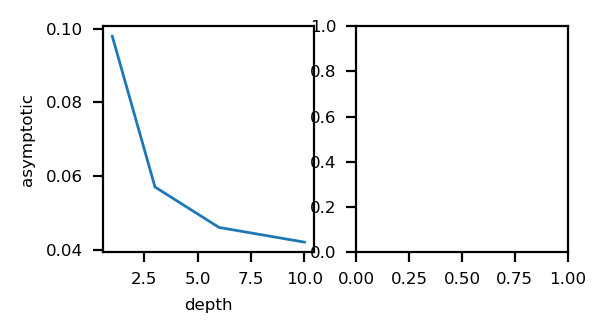

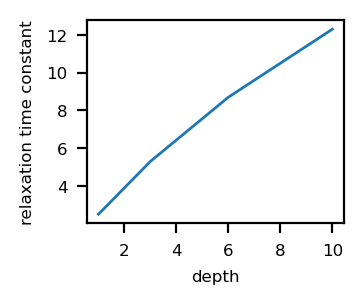

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(3, 1.5))
axes = axes.ravel()
plt.sca(axes[0])
plt.plot([1, 3, 6, 10], [0.098, 0.057, 0.046, 0.042])
plt.ylabel('asymptotic')
plt.xlabel('depth')


plt.figure()
plt.plot([1, 3, 6, 10], [2.5, 5.3, 8.7, 12.3])
plt.ylabel('relaxation time constant')
plt.xlabel('depth')
# plt.suptitle('L(t)=asympt. + (init - asympt). x e^{-t/tau}')
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

40 data objects loaded.
160 data objects loaded.


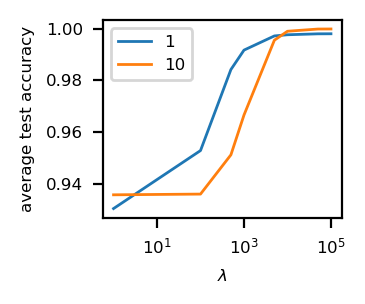

In [5]:
folder_names = ['10x1000_mnist_1L_fW0_permute0',
                '10x1000_mnist_10L_fW0_permute0']
# folder_names = ['10x1000_mnist_1L_fW0_permute1', '10x1000_mnist_1L_fW1_permute1']
key_of_data_to_plot = 'train acc'

plt.figure()
for f_name in folder_names:
    _org = ClusterResultOrganizer(local_path, batch_name=f_name)
    _org.load_all()
    _test_acc = _org.organize_results(key_of_data_to_plot, 'lambda_val')
    xaxis = []
    yaxis = []
    for key in _test_acc:
        xaxis.append(float(key))
        yaxis.append(_test_acc[key].mean(0)[:10].mean(0)[-1])
    plt.plot(xaxis, yaxis, label=_org.args.depth)
    # offset, base = exp_fit_and_plot(xaxis, _mean[:, -1][::-1], (0.9, 0.9), color='k', lw=1, ls='--')
    # print(f'offset{offset:.3f}, base{base:.3f}')
    # print(_mean[:, -1][-2] - _mean[:, -1][-3])
plt.xlabel('$\lambda$')
plt.ylabel('average test accuracy')
plt.xscale('log')
plt.legend()
# plt.xlim(-1, 5)
# plt.grid()
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'pMNIST_age_loss.svg')


40 data objects loaded.
160 data objects loaded.


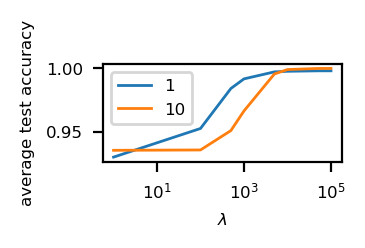

In [52]:
folder_names = ['10x1000_mnist_1L_fW0_permute0',
                '10x1000_mnist_10L_fW0_permute0']
# folder_names = ['10x1000_mnist_1L_fW0_permute1', '10x1000_mnist_1L_fW1_permute1']
key_of_data_to_plot = 'train acc'

plt.figure()
for f_name in folder_names:
    _org = cluster_utils.ClusterResultOrganizer(local_path, batch_name=f_name)
    _org.load_all()
    _test_acc = _org.organize_results(key_of_data_to_plot, 'lambda_val')
    xaxis = []
    yaxis = []
    for key in _test_acc:
        xaxis.append(float(key))
        yaxis.append(_test_acc[key].mean(0)[:10].mean(0)[-1])
    plt.plot(xaxis, yaxis, label=_org.args.depth)
    # offset, base = exp_fit_and_plot(xaxis, _mean[:, -1][::-1], (0.9, 0.9), color='k', lw=1, ls='--')
    # print(f'offset{offset:.3f}, base{base:.3f}')
    # print(_mean[:, -1][-2] - _mean[:, -1][-3])
plt.xlabel('$\lambda$')
plt.ylabel('average test accuracy')
plt.xscale('log')
plt.legend()
# plt.xlim(-1, 5)
# plt.grid()
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')


232 data objects loaded.
base:3.133, offset:0.173


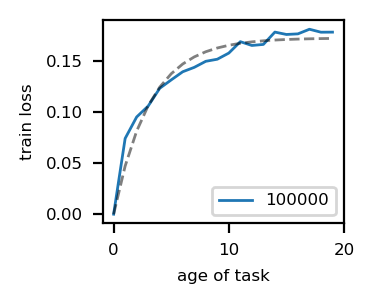

In [21]:
key_of_data_to_plot = 'train loss'
plt.figure()
_org = cluster_utils.ClusterResultOrganizer(local_path, batch_name='20x1000_fashion_10L_fW0_permute1')
_org.load_all()
_all_test_data = _org.organize_results(key_of_data_to_plot, 'lambda_val')
all_fit_bases = []
all_fit_offsets = []

for param_key in _all_test_data.keys():
    if param_key not in ['100000.0']:
        continue
    _data = _all_test_data[param_key]
    _mean = np.sqrt(_data).mean(0)
    # _std = _test_acc.std(0)
    xaxis = np.arange(_org.args.n_tasks)
    plt.plot(xaxis, _mean[:, -1][::-1],
                 label=f'{param_key[:-2]}')
    _offset, _base = exp_fit_and_plot(xaxis, _mean[:, -1][::-1], (0.1, 0.1), color='k', alpha=0.5, ls='--')
    print(f'base:{_base:.3f}, offset:{_offset:.3f}')
    all_fit_offsets.append(_offset)
    all_fit_bases.append(_base)
plt.xlabel('age of task')
plt.ylabel(key_of_data_to_plot)
plt.legend()
plt.tight_layout()
plt.xticks([0, 10, 20])
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')